# Checkpoint로 이어지는 LangGraph 대화 기억

LangGraph의 **Persistence**는 한 번의 그래프 실행이 끝난 뒤에도 State를 보존하는 기능이다. 이전 대화를 State에 저장하면 다음 질문에서 같은 대화를 이어 갈 수 있다.

## 먼저 구분할 용어

대화 기억은 모델이 내용을 내부에 외우는 기능이 아니다. LangGraph runtime이 현재 작업 데이터인 State를 저장하고, 다음 호출 전에 다시 불러오는 구조이다.

- **State**: Node들이 현재 실행에서 함께 읽고 갱신하는 작업 데이터이다. 이 실습에서는 `messages`가 대화 이력이다.
- **Checkpointer**: State를 저장하고 불러오는 저장 관리자이다.
- **Checkpoint**: 특정 실행 단계에서 저장한 State snapshot 하나이다.
- **thread**: 같은 대화에 속한 Checkpoint history이다.
- **thread_id**: 저장하거나 불러올 thread를 지정하는 key이다. 사용자 인증을 담당하지 않는다.
- **StateSnapshot**: 저장된 Checkpoint를 `get_state()`로 읽었을 때 반환되는 조회 객체이다.

핵심 흐름은 `thread_id로 thread 선택 → Checkpointer가 최신 Checkpoint 복구 → State에 새 입력 병합 → 그래프 실행 → 새 Checkpoint 저장` 순서이다.

`InMemorySaver`는 Checkpointer의 한 구현이며 Checkpoint를 현재 Python 프로세스의 RAM에 저장한다. 프로세스가 끝나면 사라지므로 수업과 개발에 적합하고, 운영 환경에서는 DB 기반 Checkpointer를 사용한다.

Checkpoint는 한 thread 안에서 이어지는 **단기 기억**을 담당한다. 여러 thread에서 공유할 사용자 선호나 장기 정보는 Store가 담당한다.

### 대화 이어가기와 중단된 실행 재개의 차이

이 실습의 이어가기는 같은 `thread_id`로 새 `graph.invoke()`를 호출해 과거 State 위에서 **새 Turn을 시작하는 방식**이다. 중단된 Node를 `Command(resume=...)`로 재개하는 Human-in-the-loop의 resume와는 다르며, 후자는 다음 노트북에서 다룬다.

## 이번 실습에서 확인할 것

같은 `thread_id`를 재사용하면 이전 `messages`가 복구되고, 다른 `thread_id`를 사용하면 대화가 분리되는지 비교한다. 마지막에는 `graph.get_state()`로 저장된 최신 State를 직접 읽는다.


## 실행 환경 준비

Persistence가 있는 Tool loop를 실행할 패키지를 현재 Jupyter 커널 환경에 설치한다.

- `langgraph`: 그래프와 `InMemorySaver`를 제공한다.
- `langchain-openai`: OpenAI Chat Model을 연결한다.
- `langchain-tavily`: 검색 Tool을 제공한다.
- `python-dotenv`: `.env`의 설정을 환경 변수로 불러온다.

DB에 저장하는 운영용 Checkpointer는 별도 패키지가 필요하지만, 이 실습은 RAM에 저장하는 `InMemorySaver`만 사용한다.


In [1]:
from langgraph import graph
from sympy import content
%pip install -U langgraph langchain-openai langchain-tavily python-dotenv


Note: you may need to restart the kernel to use updated packages.


## 모델·검색 인증과 선택 추적 설정

`.env`는 API key와 모델 ID를 코드 밖에서 관리하는 설정 파일이다. 아래 셀은 비밀값을 출력하지 않고 누락된 환경 변수의 이름만 검사한다.

- `OPENAI_API_KEY`: Chat Model 호출에 필요한 필수값이다.
- `TAVILY_API_KEY`: 검색 Tool 호출에 필요한 필수값이다.
- `OPENAI_CHAT_MODEL`: 호출할 모델 ID이며 없으면 수업용 기본값을 사용한다.
- `LANGSMITH_API_KEY`: 실행 추적에 사용하는 선택값이다. 없어도 그래프와 Checkpoint 실습은 실행된다.

`setdefault()`는 환경 변수가 없을 때만 기본값을 넣는다. 따라서 이미 정해진 LangSmith 설정을 덮어쓰지 않는다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(
    dotenv_path,
    override=False,
)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-memory")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 그래프 밖에서 검색 Tool 점검하기

`TavilySearch`는 검색어를 받아 웹 검색 결과를 반환하는 Tool이다. Checkpoint 실습에 들어가기 전에 Tool만 직접 호출해 인증·네트워크·반환 구조를 먼저 확인한다.

`max_results=2`는 한 번의 검색에서 가져올 최대 결과 수이다. 결과 수를 줄이면 이후 ToolMessage에 저장되는 검색 문맥이 불필요하게 커지는 것을 막을 수 있다.


In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)

tavily_tool.invoke({
    "query": "지금 서울 날씨는?"
})

{'query': '지금 서울 날씨는?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.aqi.in/weather/ko/south-korea/seoul/seoul',
   'title': 'Seoul 날씨 상태: 기온 | 30일 예보',
   'content': '3.6 kmph /  SW\n\n마지막 업데이트:  17 Aug 2026, 07:57 PM\n\n## FAQs About Seoul Weather Conditions\n\n1. Seoul의 오늘 18 8월 2026 현재 기온은 얼마인가요?\n\nSeoul의 현재 기온은 22°C이며, 체감 온도는 27°C입니다. 오늘 예보에 따르면 최고 기온은 31°C, 최저 기온은 22°C로 04:30 AM 18 8월 2026 기준 하루 동안 9도의 기온차가 있습니다.\n\n2. Seoul의 오늘 현재 날씨 매개변수는 무엇인가요?\n\n04:30 AM 18 8월 2026 기준 Seoul의 현재 날씨 상태에 대한 전체 개요는 다음과 같습니다:\n상태 : Fog\n기온 : 22°C 쾌적한 (체감 27°C)\n습도 : 98%\n풍속 : 3.6 km/h (SSE 방향, 163도), 돌풍 1 m/s\nUV 지수 : 0 (Low\n기압 : 1008 mb\n운량 : 100%\n시정 : 0 km\n강수량 : 0 mm (강우 확률 38%) [...] 04:30 AM 18 8월 2026부터 Seoul의 10일 예보는 다음 추세를 보입니다:\n오늘 (8월 18) : 기온 26°C, 습도 75% 및 Sunny 상태.\n수요일 (8월 19) : 기온 26°C, 습도 73% 및 Overcast 상태.\n목요일 (8월 20) : 기온 26°C, 습도 72% 및 Overcast 상태.\n금요일 (8월 21) : 기온 23°C, 습도 88% 및 Rain Shower 상태.\n토요일 (8월 22) : 기온 25°C, 습도 

## Chat Model에 검색 Tool 사용법 연결하기

`bind_tools()`는 Chat Model에 Tool의 이름·설명·입력 schema를 알려 준다. 모델은 검색이 필요하다고 판단하면 `tool_calls`를 포함한 `AIMessage`를 반환한다.

이 단계는 Tool을 **실행**하지 않는다. 실제 Tool 호출은 뒤에서 등록할 `ToolNode`가 담당한다.


In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model_name=OPENAI_CHAT_MODEL,
    use_responses_api=True,
)

tools = [tavily_tool]

llm_with_tools = llm.bind_tools(tools)

## Checkpoint 대화 기억을 완성할 네 구성 요소

여기까지 만든 `llm_with_tools`는 Tool 요청을 만들 수 있지만, 대화 이력을 저장하거나 다음 호출에서 복구하지는 않는다. 기억이 있는 Tool loop를 만들려면 다음 네 구성 요소를 연결해야 한다.

1. `State`: 저장할 `messages`와 새 message를 합치는 규칙이다.
2. `chatbot`: 복구된 `messages`를 읽어 다음 `AIMessage`를 만드는 Node이다.
3. `Checkpointer`: 실행 단계별 State를 `thread_id`에 따라 저장하고 불러오는 객체이다.
4. `CompiledStateGraph`: Node·Edge를 실행하고 Checkpointer에 저장 시점을 알려 주는 runtime이다.

```text
새 HumanMessage + thread_id
            ↓
Checkpointer가 최신 Checkpoint의 messages 복구
            ↓
add_messages로 새 입력 병합 → chatbot ↔ tools
            ↓
실행 단계별 새 Checkpoint 저장 → 최종 State 반환
```

### 1. Checkpoint에 저장할 messages State 규칙 정의하기

Checkpointer가 저장하는 대상은 모델 자체가 아니라 **그래프 State**이다. <br>
State는 `messages` key 하나만 가지며 사용자·모델·Tool message가 실행 순서대로 들어간다.

- 입력: Checkpoint에서 복구한 기존 `messages`와 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 새 message를 기존 목록 뒤에 병합한다.
- 출력: 다음 Node와 다음 Turn이 읽을 수 있는 갱신된 `messages`이다.
- 다음 사용처: Checkpointer가 갱신된 State를 새 Checkpoint로 저장한다.

같은 `thread_id`의 Checkpoint를 복구한 뒤 새 입력을 넣어도 과거 대화가 사라지지 않는 이유가 이 병합 규칙이다.


In [7]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### 2. 복구된 대화를 읽는 chatbot Node 정의하기

`chatbot()`은 현재 thread의 `messages`를 모델에 전달하고 새 `AIMessage`를 State update로 반환한다. 뒤에서 `add_node()`로 등록하면 그래프의 Node가 된다.

- 입력: Checkpoint에서 복구된 과거 message와 현재 Turn의 새 `HumanMessage`가 합쳐진 State이다.
- 변환: `llm_with_tools`가 전체 대화를 읽고 일반 답변 또는 Tool 요청을 만든다.
- 출력: `add_messages`에 전달할 새 `AIMessage` 하나이다.
- 다음 사용처: Tool 요청 유무에 따라 Tool Node 또는 종료 경로로 이동하고, 갱신된 State는 Checkpoint에 저장된다.

Node는 Checkpointer를 직접 호출하지 않는다. Node가 State update를 반환하면 LangGraph runtime이 실행 단계의 경계에서 저장을 요청한다. 이 셀은 함수 정의 단계이므로 모델 API는 아직 호출하지 않는다.


In [8]:
# 전달 받은 State에는 복구된 이전 대화 내역이 담겨있다
def chatbot(state: State) -> dict:
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}

### 3. State를 저장할 Checkpointer 만들기


![LangGraph 공식 Checkpoint 구조](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/04_official_checkpoints.png)

1. **Graph**: State가 Node와 Edge를 따라 이동한다.
2. **Super-step**: 현재 실행할 Node 묶음 하나가 한 단계가 된다. 순차 Node는 각각 별도 단계이다.
3. **Checkpoint**: 각 단계 경계에서 State·`next`·ID 등의 snapshot을 저장한다.
4. **Thread**: 같은 `thread_id`에 속한 Checkpoint들을 하나의 history로 관리한다.
5. **StateSnapshot**: 저장된 Checkpoint를 Python에서 조회할 때 사용하는 객체이다.

출처: [LangGraph Checkpointers 문서](https://docs.langchain.com/oss/python/langgraph/checkpointers)

---

`InMemorySaver`는 위 Checkpoint들을 RAM에 저장하는 Checkpointer이다.

- 입력: 컴파일된 그래프가 전달하는 `thread_id`와 실행 단계별 State snapshot이다.
- 변환: 같은 `thread_id`의 Checkpoint들을 하나의 thread history로 구분해 보관한다.
- 출력: 다음 호출에서 복구할 최신 Checkpoint와 조회 가능한 StateSnapshot이다.
- 다음 사용처: `compile(checkpointer=checkpointer)`가 이 객체를 그래프 runtime에 연결한다.

`InMemorySaver()` 객체를 만드는 것만으로는 아무 State도 저장되지 않는다. Python 프로세스가 끝나면 기록도 모두 사라지므로, 재시작 복구가 필요한 운영 서비스에는 PostgresSaver 같은 DB 기반 구현을 사용한다.


In [9]:
from langgraph.checkpoint.memory import InMemorySaver

# 현재 jupyter server 메모리를 저장소로 사용
checkpointer = InMemorySaver()

### 4. 네 구성 요소를 Persistence가 있는 Tool loop로 조립하기

이제 앞에서 정의한 부품을 `StateGraph`에 등록하고 Checkpointer와 함께 컴파일한다.

`prebuilt`는 반복해서 사용하는 표준 로직을 LangGraph가 미리 구현해 둔 구성 요소이다.<br>
`ToolNode`와 `tools_condition`를 직접 구현하지 않고 `langgraph.prebuilt`에서 제공되는 것을 사용한다.

- `State` → `StateGraph(State)`의 공유 데이터 schema이다.
- `chatbot` → 모델의 다음 행동을 만드는 `"chatbot"` Node이다.
- `ToolNode(tools)` → 모델의 `tool_calls`를 실제 실행하는 `"tools"` Node이다.
- `tools_condition` → Tool 실행과 종료 중 다음 경로를 고르는 route function이다.
- `checkpointer` → `compile(checkpointer=...)`에서 thread별 Persistence를 담당한다.

`ToolNode`와 `tools_condition`은 Tool 실행 흐름을 담당하고, 대화 기억은 `checkpointer`가 담당한다.

```text
START → chatbot → tools_condition
                    ├─ tools → chatbot
                    └─ END

각 실행 단계의 State ── checkpointer ──> thread_id별 Checkpoint
```

`compile()`의 출력은 실행 가능한 `CompiledStateGraph`이다. 이 셀에서는 구조만 조립하므로 모델·Tool 호출과 Checkpoint 저장은 일어나지 않는다. `checkpointer` 인자를 생략하면 `thread_id`를 전달해도 이전 State가 자동으로 복구되지 않는다.


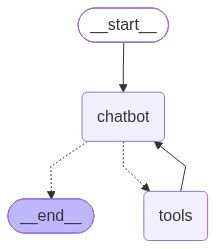

In [11]:
from langgraph.graph import END, START, StateGraph

from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)

# 노드 등록
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", ToolNode(tools)) # Prebuilt ToolNode

# 엣지 연결
workflow.add_edge(START, "chatbot")
workflow.add_edge("tools", "chatbot")


# 조건 분기 설정
workflow.add_conditional_edges(
    "chatbot",      # 분기할 Node
    tools_condition
    # "chatbot" Node에서 반환되는 마지막 AIMessage에
    # tool_calls가 있다면 "tools", 없으면 END 반환
)

graph = workflow.compile(
    # 단계별 State를 thread_id 기준 CheckPoint로 저장한ㄷ.
    checkpointer=checkpointer,
) # 실행 가능한 형태로 변경

display(graph)

## thread_id로 실제 저장·복구 흐름 확인하기

앞의 셀들은 기억에 필요한 규칙과 객체를 정의했다. 이제 `graph.invoke()`를 호출하면 처음으로 모델·Tool loop가 실행되고 Checkpointer가 State를 저장한다.

각 호출은 다음 순서로 처리된다.

1. 입력 State update와 `configurable.thread_id`를 받는다.
2. 같은 thread의 최신 Checkpoint가 있으면 State를 복구한다.
3. `add_messages`가 새 `HumanMessage`를 기존 이력 뒤에 합친다.
4. 그래프를 실행하고 단계별 State를 새 Checkpoint로 저장한다.
5. 누적된 `messages`를 포함한 최종 State를 반환한다.

### 1. user1 thread에 첫 번째 Turn 저장하기

**Turn**은 사용자 입력과 그에 대한 모델 응답이 오가는 대화 한 차례이다. 첫 호출의 `thread_id`를 `user1`로 지정하고 이름이 포함된 `HumanMessage`를 전달한다.

아직 user1의 과거 Checkpoint가 없으므로 새 State에서 시작한다. `graph.invoke()`가 끝나면 실행 단계별 Checkpoint가 user1의 history에 추가되고, 최신 Checkpoint에는 사용자 입력과 모델 응답이 포함된다. 첫 Turn만으로는 기억을 증명할 수 없으므로 다음 셀에서 같은 `thread_id`를 재사용한다.


In [12]:
from langchain_core.messages import HumanMessage

# CheckPointer가 user1의 저장 위치를 선택하게 하기 위한 설정이다.
user_config = {
    "configurable" : {
        "thread_id": "user1",
    }
}

# llm에게 전달할 첫 메시지(첫 Turn)
user_input = {
    "messages":[HumanMessage(content="반가워. 내 이름은 홍길동이야")]
}

user1_state = graph.invoke(
    user_input, # 초기 State
    config=user_config,   # 'user1' CheckPoint를 저장하고 불러올 thread 지정
)

user1_state["messages"][-1].content

[{'type': 'text',
  'text': '반가워요, 홍길동님! 무엇을 도와드릴까요?',
  'annotations': [],
  'id': 'msg_06661232d3900480006a83ee31344087d0b862f38ecdf6cd30',
  'phase': 'final_answer'}]

### 2. 같은 user1 thread에서 이전 이름 회상하기

후속 호출에는 새 질문만 전달한다. 그러나 같은 `user1_config`를 사용하므로 Checkpointer가 user1의 최신 Checkpoint를 불러오고, `add_messages`가 새 질문을 과거 대화 뒤에 병합한다.

- 입력: 이름이 없는 새 질문과 `thread_id="user1"`이다.
- 변환: user1의 과거 `messages` 복구 → 새 질문 병합 → chatbot 실행 순서이다.
- 출력: 과거 이름을 근거로 만든 최신 `AIMessage`이다.
- 다음 사용처: 이번 Turn까지 포함한 State가 user1의 새 Checkpoint로 저장된다.

답변에 첫 Turn의 이름이 반영되면 모델이 숨겨서 기억한 것이 아니라 **복구된 messages를 다시 읽은 것**이다.


In [13]:
user_input2 = {
    "messages" : [
        HumanMessage(content="내 이름이 뭐라고?")
    ]
}

user1_state = graph.invoke(
    user_input2,
    config=user_config
)

user1_state["messages"][-1].content

[{'type': 'text',
  'text': '홍길동님이에요.',
  'annotations': [],
  'id': 'msg_06661232d3900480006a83efc4208087d0a798f72f6e8f4b00',
  'phase': 'final_answer'}]

### 3. 다른 user2 thread가 분리되는지 확인하기

`thread_id="user2"`는 user1과 다른 Checkpoint history를 가리킨다. 같은 graph와 Checkpointer를 사용해도 `thread_id`가 다르면 user1의 messages를 불러오지 않는다.

- 입력: 이름을 묻는 질문과 새 `thread_id="user2"`이다.
- 변환: user2의 저장 기록만 조회하며, 기록이 없으므로 새 State에서 그래프를 실행한다.
- 출력: user1의 이름을 근거로 사용하지 않은 최신 `AIMessage`이다.
- 다음 사용처: user2의 첫 State가 user1과 별도의 Checkpoint로 저장된다.

user2의 답변이 user1의 이름을 근거로 사용하지 않아야 thread 격리가 유지된 것이다. 단, `thread_id`는 저장 key일 뿐 인증 수단은 아니므로 서비스에서는 접근 권한을 별도로 검사해야 한다.


In [14]:
user222_config = { # 새로운 thread_id 설정
    "configurable" : {
        "thread_id": "user222",
    }
}

user222_input = {
    "messages" : [
        HumanMessage(content="내 이름이 뭐라고?")
    ]
}

user222_state = graph.invoke(
    user222_input,
    config=user222_config
)

user222_state["messages"][-1].content

[{'type': 'text',
  'text': '아직 이름을 알려주지 않으셔서 모르겠어요.',
  'annotations': [],
  'id': 'msg_013deadda1fcfcad006a83f11bf100819b9f2e3108e265b3d1',
  'phase': 'final_answer'}]

### 4. user1 thread로 돌아와 세 번째 Turn 이어 가기

user2 호출 뒤 다시 `user1_config`를 전달한다. Checkpointer는 호출 순서가 아니라 `thread_id`를 기준으로 저장 위치를 선택하므로 user1의 최신 Checkpoint를 다시 복구한다.

- 입력: 새 주제와 이름 회상을 함께 요구하는 질문, `thread_id="user1"`이다.
- 변환: user1의 두 Turn 복구 → 새 질문 병합 → 그래프 실행 순서이다.
- 출력: 새 주제와 저장된 이름을 함께 반영한 최신 `AIMessage`이다.
- 다음 사용처: 세 번째 Turn까지 포함한 State가 user1 history의 최신 Checkpoint가 된다.

이 결과로 서로 다른 thread의 호출이 중간에 끼어도 user1의 대화가 독립적으로 이어지는지 확인한다.


In [15]:
user_input3 = {
    "messages" : [
        HumanMessage(content="LangGraph 복습 계획 간략히 세우고, 내 이름도 알려줘")
    ]
}

user1_state = graph.invoke(
    user_input3,
    config=user_config
)

user1_state["messages"][-1].content

[{'id': 'rs_06661232d3900480006a83f1a781e487d089c94c657da46040',
  'summary': [],
  'type': 'reasoning',
  'content': [],
  'encrypted_content': 'gAAAAABqg_GpoT-RcO6LmISyjU2oOT9UrN_XtDEZRLqQZhnCGeWFNp2bOHGcBTsGYEPTHwRP4pNJgMP5zrj-9soE_CSoM5C-i0lJWAGHLeRowiU1yAH1TWVEgFY885acvo4R4rh-yRLBPnLFKnvHrbSAe1uLf0g0B2VcrMtpjDw8filYnj1ms6_rQeinE7pHY198Oovk8U8AWNypBgqwxzgoR1ElceOa8rIYDHprb9h3eDsm5FOJlXwSunEhEGj___bsgv53Duw_3-HcGm_Z52Db6eog8MZxh9jn6H7I43q5ZokqQc-lxH9IGu5MfIUZdEjkbaAawAsmGz53D62W6D6iPfaRSY1LS8EGrKUrjUbQyOT2D6bjY85xu7L0mUrEDyHA8uqZPcnO8VFiyprVfRFmVMXPfLAe4ZZGTvri3Zh9LXxv1JlxZtPlsi89lcOgRfbvO6CnPCZF9FFJxU7VdRL_KkDs5NBFsyrEiuSXgRIUFMmC9MssYkc6VqwdEYy8khkniKX_Hg_wg84jvqfVpY8ZVuLigKzMqfAz198R5ryDIqunCx6XWFBd3ZfsJxchjGXh8GqZD_unFMDXTstdNQKpKzU2mXHj9pHslzic-hOunnRbdh5nqYtWLkUF5XTfHXpST-cc1nB6eqKRmTB0fBQaisL6XmZ388qjTM0vDDzyc-2TuxY7CmmAkE3DIoSsha3ijxQgg9v2HrWraZrSJNTaZ5zD7d0zQhkpIFfM7Vl5h1LvXo3IAIc8B1kljzg7dMnzhe5L5o2i1c4pU9x137NOML6wN_BR7Yiuv0fyEHqK47dGlxoYeRsJOMwdtftWGMYURHFwxOjRr37CSDUhCQ

## 저장된 최신 Checkpoint를 StateSnapshot으로 확인하기

**Checkpoint**는 Checkpointer에 저장된 기록이고, **StateSnapshot**은 그 기록을 Python에서 조회할 때 받는 객체이다. `graph.get_state(user1_config)`는 user1 thread의 **최신 Checkpoint 하나**를 StateSnapshot으로 반환한다.

**두 필드 확인**

- `values`: 해당 시점의 실제 State 값이다. 여기에는 누적된 `messages`가 들어 있다.
- `next`: 다음에 실행할 Node 이름의 tuple이다. 그래프가 정상 종료되었으면 빈 tuple `()`이고, 값이 남아 있으면 중단되었거나 이어서 실행할 Node가 있다는 뜻이다.

입력은 `thread_id="user1"`인 config이고, 출력은 조회 전용 StateSnapshot이다.

### history와 resume의 범위

- `graph.get_state()`: thread의 최신 snapshot 하나를 조회한다.
- `graph.get_state_history()`: 같은 thread에 쌓인 여러 snapshot을 순서대로 조회할 때 사용하는 별도 API이다. 이 실습에서는 호출하지 않는다.
- 같은 `thread_id`의 새 `graph.invoke()`: 최신 State를 복구한 뒤 새 Turn을 실행하는 **대화 이어가기**이다.
- `Command(resume=...)`: interrupt로 멈춘 실행에 사람의 값을 전달해 재개하는 **중단 지점 resume**이다. 다음 Human-in-the-loop 노트북에서 다룬다.

Tool 호출 여부에 따라 message 수는 달라질 수 있으므로 고정 숫자보다 user1의 세 Turn이 순서대로 포함되는지를 확인한다.


In [18]:
user1_snapshot = graph.get_state(user_config)

print("message count:", len(user1_snapshot.values["messages"]))

# END로 끝난 상태이기 때문에 다음 Node 없음 == ()
print("next nodes:", user1_snapshot.next)

display(user1_snapshot.values["messages"])

message count: 6
next nodes: ()


[HumanMessage(content='반가워. 내 이름은 홍길동이야', additional_kwargs={}, response_metadata={}, id='382c96cf-2d52-4273-a1c1-f232ab111304'),
 AIMessage(content=[{'type': 'text', 'text': '반가워요, 홍길동님! 무엇을 도와드릴까요?', 'annotations': [], 'id': 'msg_06661232d3900480006a83ee31344087d0b862f38ecdf6cd30', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_06661232d3900480006a83ee30714487d08f59096e2e891225', 'created_at': 1787031088.0, 'metadata': {}, 'model': 'gpt-5.6-luna', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna'}, id='resp_06661232d3900480006a83ee30714487d08f59096e2e891225', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1181, 'output_tokens': 22, 'total_tokens': 1203, 'input_token_details': {'cache_creation': 1178, 'cache_read': 0}, 'output_token_details': {'reasoning': 0}}),
 HumanMessage(content='내 이름이 뭐라고?', additional_kwargs={}, response_metadata={}, id='3cdc54e

In [19]:
# 도구 호출 후 내역을 checkpoint에 기록
user_input4 = {
    "messages":[
        HumanMessage(
            content="리센느가 누구야?"
        )
    ]
}

user1_state = graph.invoke(
    user_input4,
    config=user_config
)

user1_state["messages"][-1].text

'**리센느(RESCENE)**는 **더뮤즈엔터테인먼트 소속의 5인조 K-pop 걸그룹**이에요. 2024년 3월 데뷔했으며, 멤버는 **원이(Woni), 미나미(Minami), 메이(May), 제나(Zena), 리브(Liv)**입니다.\n\n그룹명은 **‘향기’를 뜻하는 Scent와 ‘장면’을 뜻하는 Scene**을 결합해, 음악으로 특별한 장면과 기억을 만든다는 의미를 담고 있어요. 대표곡으로는 **〈UhUh〉, 〈YoYo〉** 등이 있습니다.'

In [20]:
user1_snapshot = graph.get_state(user_config)
display(user1_snapshot.values["messages"])

[HumanMessage(content='반가워. 내 이름은 홍길동이야', additional_kwargs={}, response_metadata={}, id='382c96cf-2d52-4273-a1c1-f232ab111304'),
 AIMessage(content=[{'type': 'text', 'text': '반가워요, 홍길동님! 무엇을 도와드릴까요?', 'annotations': [], 'id': 'msg_06661232d3900480006a83ee31344087d0b862f38ecdf6cd30', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_06661232d3900480006a83ee30714487d08f59096e2e891225', 'created_at': 1787031088.0, 'metadata': {}, 'model': 'gpt-5.6-luna', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna'}, id='resp_06661232d3900480006a83ee30714487d08f59096e2e891225', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1181, 'output_tokens': 22, 'total_tokens': 1203, 'input_token_details': {'cache_creation': 1178, 'cache_read': 0}, 'output_token_details': {'reasoning': 0}}),
 HumanMessage(content='내 이름이 뭐라고?', additional_kwargs={}, response_metadata={}, id='3cdc54e